# Two POVs + frozen feature extractor + regressor

This notebook trains and evaluates different combinations of frozen feature extractors, POV fusion strategies and regressors on the top+side dataset.


In [1]:
import datetime
import warnings
from IPython.display import display
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.model_selection import ParameterGrid
from sklearn.svm import SVR
from src.helpers import *
from src.frozen_pipeline import *
from src.training_an_evaluation import *

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 200)


## Setup


In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
OUTER_SPLITS = 5
INNER_SPLITS = 5

CSV_PATH = Path("experiments/experiments_1_36.csv")
TOP_FOLDER = Path("photos/top_view_images")
SIDE_FOLDER = Path("photos/side_view_images")
EMBEDDING_CACHE_DIR = Path("embeddings")
EMBEDDING_CACHE_DIR.mkdir(exist_ok=True)
OUTPUT_DIR = Path("results")
OUTPUT_DIR.mkdir(exist_ok=True)

BACKBONE_NAMES = [
    "resnet50",
    # "convnext_tiny",
    # "densenet121",
]

FUSION_NAMES = [
    "concat",
    # "mean",
    # "max",
    # "concat_abs_diff",
]

REGRESSION_MODEL_CONFIGS = {
    "dummy_mean": (
        DummyRegressor(strategy="mean"),
        {},
    ),

    "ridge": (
        make_pipeline(Ridge()),
        {
            "model__alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
        },
    ),

    "elasticnet": (
        make_pipeline(ElasticNet(max_iter=20000)),
        {
            "model__alpha":    [0.0001, 0.001, 0.01, 0.1, 1.0],
            "model__l1_ratio": [0.1, 0.2, 0.5, 0.8, 0.9],
        },
    ),

    "random_forest": (
        # No scaler needed for trees, but consistency yk
        Pipeline([
            ("imputer", SimpleImputer(strategy="mean")),
            ("model",   RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1)),
        ]),
        {
            "model__n_estimators":    [100, 300, 500],
            # "model__max_depth":       [None, 5, 10]   # Seemed to always select None anyway
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features":    [0.3, 0.5, 1.0]
        },
    ),

    "svr": (
        make_pipeline(SVR()),
        {
            "model__C": [0.1, 1, 10, 100],
            "model__gamma": ["scale", 0.01, 0.1],
            "model__epsilon": [0.01, 0.1, 1]
        }
    ),

    # "extra_trees": (
    #     Pipeline([
    #         ("imputer", SimpleImputer(strategy="mean")),
    #         ("model",   ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=1)),
    #     ]),
    #     {
    #         "model__n_estimators":    [100, 300, 500],
    #         # "model__max_depth":       [None, 5, 10],
    #         "model__min_samples_leaf":[1, 2, 4],
    #         "model__max_features":    [0.3, 0.5, 1.0],
    #     },
    # ),
}


## Data loading


In [3]:
samples, image_paths = load_image_paths(CSV_PATH, TOP_FOLDER, SIDE_FOLDER)
print("Samples shape:", samples.shape)
display(samples[["exp_id", "volume", "top_path", "side_path"]].head())


Samples shape: (140, 23)


,exp_id,volume,top_path,side_path
0,1,38,photos/top_view_images/P2090072.JPG,photos/side_view_images/P2090161.JPG
1,1,57,photos/top_view_images/P2090073.JPG,photos/side_view_images/P2090163.JPG
2,1,76,photos/top_view_images/P2090074.JPG,photos/side_view_images/P2090167.JPG
3,2,19,photos/top_view_images/P2090075.JPG,photos/side_view_images/P2090171.JPG
4,2,38,photos/top_view_images/P2090076.JPG,photos/side_view_images/P2090173.JPG


## Regression model configuration


In [4]:
print("Grid sizes per regressor:")
for name, (_, grid) in REGRESSION_MODEL_CONFIGS.items():
    n = len(list(ParameterGrid(grid))) if grid else 1
    print(f"  {name:15s}: {n:4d}")

Grid sizes per regressor:
  dummy_mean     :    1
  ridge          :    7
  svr            :   36


## Nested CV evaluation over backbone, fusion and regression model combinations


In [5]:
all_results = []
nested_artifacts = {}

for backbone_name in BACKBONE_NAMES:
    for fusion_name in FUSION_NAMES:
        print(f"\n{'#'*90}")
        print(f"Evaluating backbone={backbone_name}, fusion={fusion_name}")
        print(f"{'#'*90}")

        X, y, groups = build_feature_matrix(samples, backbone_name, fusion_name, EMBEDDING_CACHE_DIR, DEVICE)
        nested_results, oof_predictions = run_nested_cv(
            X=X,
            y=y,
            groups=groups,
            model_configs=REGRESSION_MODEL_CONFIGS,
            outer_splits=OUTER_SPLITS,
            inner_splits=INNER_SPLITS,
        )

        summary_df = summarise_nested_results(nested_results, backbone_name, fusion_name)
        display(summary_df)
        all_results.append(summary_df)
        nested_artifacts[(backbone_name, fusion_name)] = {
            "X": X,
            "y": y,
            "groups": groups,
            "nested_results": nested_results,
            "oof_predictions": oof_predictions,
        }

results_df = pd.concat(all_results, ignore_index=True).sort_values(
    ["cv_mae_mean", "cv_rmse_mean", "cv_r2_mean"],
    ascending=[True, True, False],
).reset_index(drop=True)

print("Overall summary:")
display(results_df)



##########################################################################################
Evaluating backbone=resnet50, fusion=concat
##########################################################################################


resnet50 + concat: 100%|██████████| 140/140 [00:00<00:00, 3688.46it/s]


dummy_mean
Fold 1: MAE=19.000, RMSE=21.243, R2=0.000, best={}
Fold 2: MAE=19.000, RMSE=21.243, R2=0.000, best={}
Fold 3: MAE=19.000, RMSE=21.248, R2=-0.001, best={}
Fold 4: MAE=18.657, RMSE=20.940, R2=-0.004, best={}
Fold 5: MAE=19.355, RMSE=21.557, R2=-0.000, best={}

ridge


Fold 1: MAE=6.068, RMSE=7.774, R2=0.866, best={'model__alpha': 1000.0}
Fold 2: MAE=48.920, RMSE=220.531, R2=-106.776, best={'model__alpha': 1000.0}
Fold 3: MAE=7.402, RMSE=8.725, R2=0.831, best={'model__alpha': 1000.0}
Fold 4: MAE=6.974, RMSE=9.170, R2=0.807, best={'model__alpha': 1000.0}
Fold 5: MAE=7.857, RMSE=9.684, R2=0.798, best={'model__alpha': 1000.0}

svr
Fold 1: MAE=11.405, RMSE=13.835, R2=0.576, best={'model__C': 100, 'model__epsilon': 0.01, 'model__gamma': 'scale'}
Fold 2: MAE=11.317, RMSE=13.355, R2=0.605, best={'model__C': 100, 'model__epsilon': 0.01, 'model__gamma': 'scale'}
Fold 3: MAE=10.941, RMSE=12.488, R2=0.654, best={'model__C': 100, 'model__epsilon': 0.01, 'model__gamma': 'scale'}
Fold 4: MAE=9.304, RMSE=11.896, R2=0.676, best={'model__C': 100, 'model__epsilon': 0.01, 'model__gamma': 'scale'}
Fold 5: MAE=11.590, RMSE=14.618, R2=0.540, best={'model__C': 100, 'model__epsilon': 0.01, 'model__gamma': 'scale'}


,backbone,fusion,regressor,cv_mae_mean,cv_mae_std,cv_mse_mean,cv_mse_stc,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,resnet50,concat,svr,10.911302,0.831138,176.179292,25.510889,13.238267,0.963113,0.610134,0.049799
1,resnet50,concat,ridge,15.444327,16.748022,9789.655727,19422.095844,51.176855,84.679308,-20.694609,43.040615
2,resnet50,concat,dummy_mean,19.002491,0.220582,451.432182,8.290007,21.246038,0.195063,-0.001153,0.001478


Overall summary:


,backbone,fusion,regressor,cv_mae_mean,cv_mae_std,cv_mse_mean,cv_mse_stc,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,resnet50,concat,svr,10.911302,0.831138,176.179292,25.510889,13.238267,0.963113,0.610134,0.049799
1,resnet50,concat,ridge,15.444327,16.748022,9789.655727,19422.095844,51.176855,84.679308,-20.694609,43.040615
2,resnet50,concat,dummy_mean,19.002491,0.220582,451.432182,8.290007,21.246038,0.195063,-0.001153,0.001478


## Inspect selected hyperparameters


In [6]:
for (backbone_name, fusion_name), artifact in nested_artifacts.items():
    print(f"\n{'='*90}")
    print(f"backbone={backbone_name}, fusion={fusion_name}")
    print(f"{'='*90}")
    for regressor_name, folds in artifact["nested_results"].items():
        has_params = any(f["best_params"] for f in folds)
        if not has_params:
            continue
        print(regressor_name)
        for f in folds:
            print(f"  Fold {f['fold']}: {f['best_params']}")
        print()



backbone=resnet50, fusion=concat
ridge
  Fold 1: {'model__alpha': 1000.0}
  Fold 2: {'model__alpha': 1000.0}
  Fold 3: {'model__alpha': 1000.0}
  Fold 4: {'model__alpha': 1000.0}
  Fold 5: {'model__alpha': 1000.0}

svr
  Fold 1: {'model__C': 100, 'model__epsilon': 0.01, 'model__gamma': 'scale'}
  Fold 2: {'model__C': 100, 'model__epsilon': 0.01, 'model__gamma': 'scale'}
  Fold 3: {'model__C': 100, 'model__epsilon': 0.01, 'model__gamma': 'scale'}
  Fold 4: {'model__C': 100, 'model__epsilon': 0.01, 'model__gamma': 'scale'}
  Fold 5: {'model__C': 100, 'model__epsilon': 0.01, 'model__gamma': 'scale'}



## Plot out-of-fold predictions for the best configurations


,backbone,fusion,regressor,cv_mae_mean,cv_mae_std,cv_mse_mean,cv_mse_stc,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std
0,resnet50,concat,svr,10.911302,0.831138,176.179292,25.510889,13.238267,0.963113,0.610134,0.049799
1,resnet50,concat,ridge,15.444327,16.748022,9789.655727,19422.095844,51.176855,84.679308,-20.694609,43.040615
2,resnet50,concat,dummy_mean,19.002491,0.220582,451.432182,8.290007,21.246038,0.195063,-0.001153,0.001478


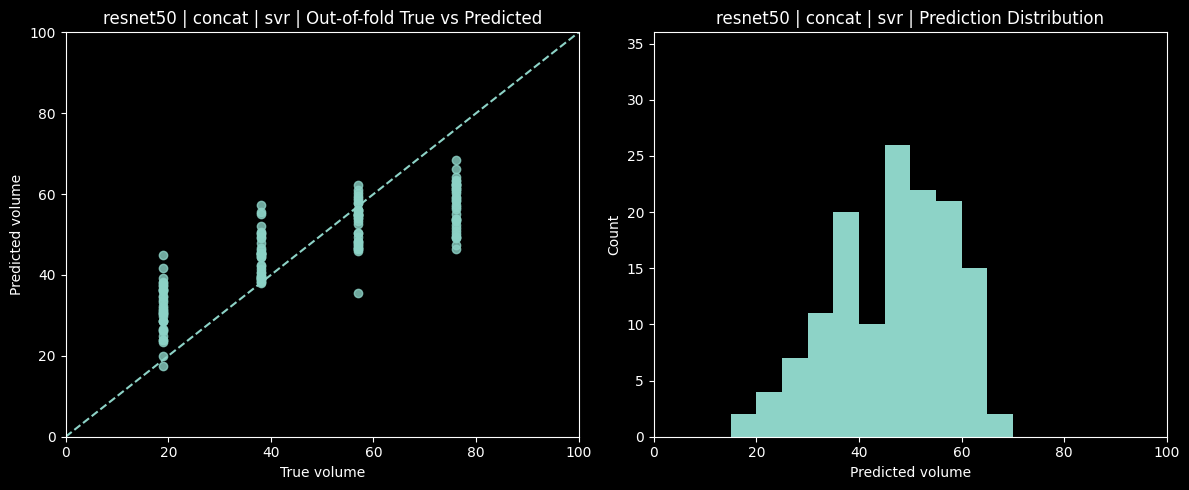

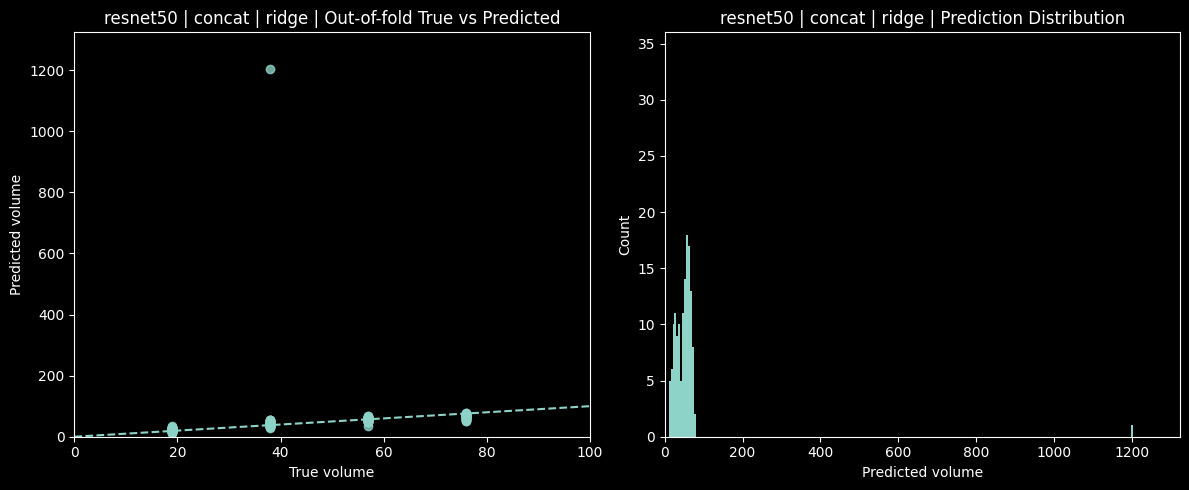

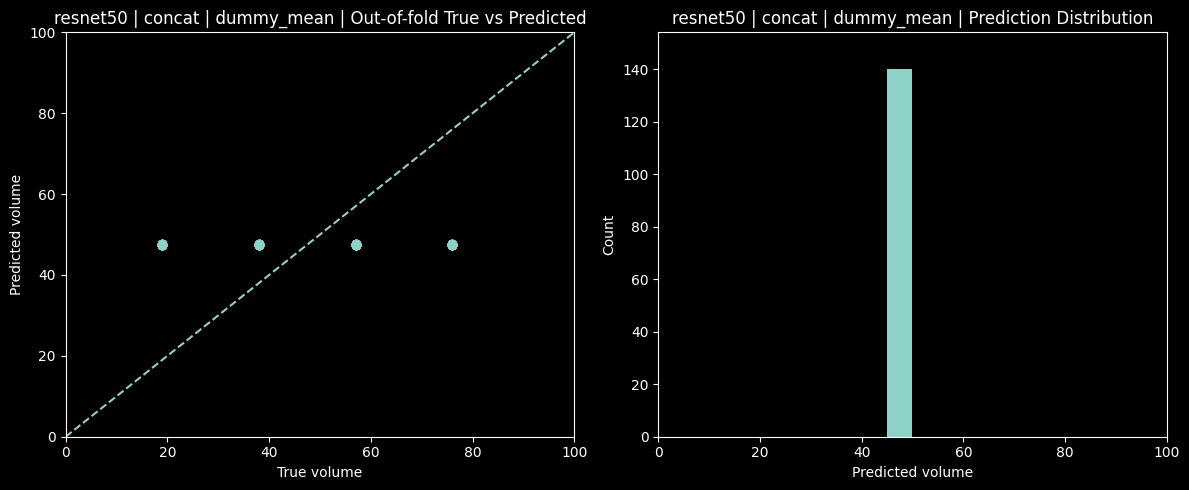

In [7]:
TOP_K_TO_PLOT = 6
best_rows = results_df.head(TOP_K_TO_PLOT)
display(best_rows)

for _, row in best_rows.iterrows():
    key = (row["backbone"], row["fusion"])
    artifact = nested_artifacts[key]
    y_true = artifact["y"]
    y_pred = artifact["oof_predictions"][row["regressor"]]
    title = f"{row['backbone']} | {row['fusion']} | {row['regressor']}"
    make_oof_plot(y_true, y_pred, title_prefix=title)


## Export summary tables


In [8]:
timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
name = f"results_frozen_{timestamp}.csv"
results_df.to_csv(OUTPUT_DIR / name, index=False)
print("Saved:", OUTPUT_DIR / name)


Saved: results/results_frozen_2026-03-20_06-15-16.csv
